In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, f1_score

In [2]:
df = pd.read_csv('/content/bank-full.csv', sep=';')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45210 entries, 0 to 45209
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45210 non-null  int64 
 1   job        45210 non-null  object
 2   marital    45210 non-null  object
 3   education  45210 non-null  object
 4   default    45210 non-null  object
 5   balance    45210 non-null  int64 
 6   housing    45210 non-null  object
 7   loan       45210 non-null  object
 8   contact    45210 non-null  object
 9   day        45210 non-null  int64 
 10  month      45210 non-null  object
 11  durations  45210 non-null  int64 
 12  campaign   45210 non-null  int64 
 13  pdays      45210 non-null  int64 
 14  previous   45210 non-null  int64 
 15  poutcome   45210 non-null  object
 16  y          45210 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
df['y'].value_counts(normalize=True)

,proportion
y,
no,0.883013
yes,0.116987


# **Encoding**

In [5]:
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [6]:
X = df.drop('y', axis=1)
y = df['y']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Training and Evaluation**

In [9]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression(max_iter=1000)

In [10]:
rf.fit(X_train, y_train)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [11]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [12]:
print(f"Random Forest F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"Logistic Regression F1-Score: {f1_score(y_test, lr.predict(X_test_scaled)):.4f}")

Random Forest F1-Score: 0.5265
Logistic Regression F1-Score: 0.3108


# **Model Using SHAP**

In [13]:
import shap

In [15]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test.iloc[:5])

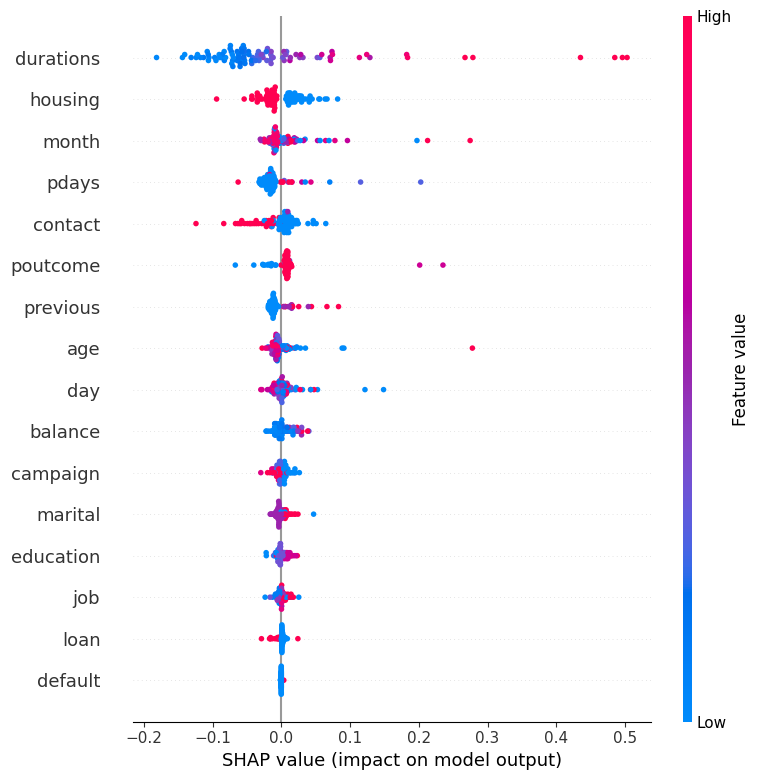

In [20]:
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[0,:,1], X_test.iloc[0,:])

shap.summary_plot(explainer.shap_values(X_test.iloc[:100])[:, :, 1], X_test.iloc[:100])

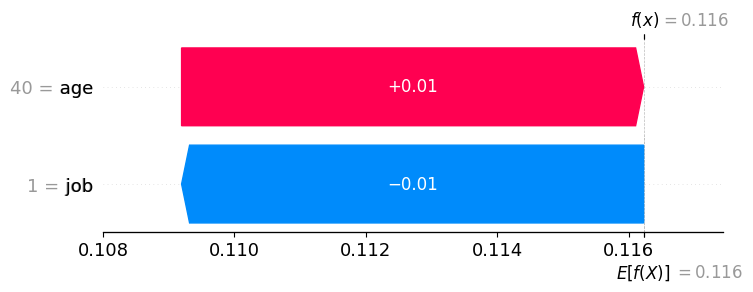

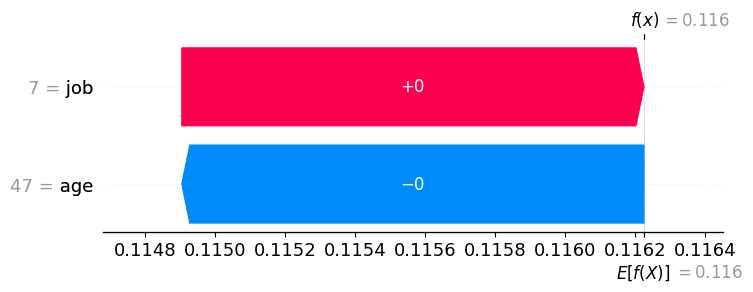

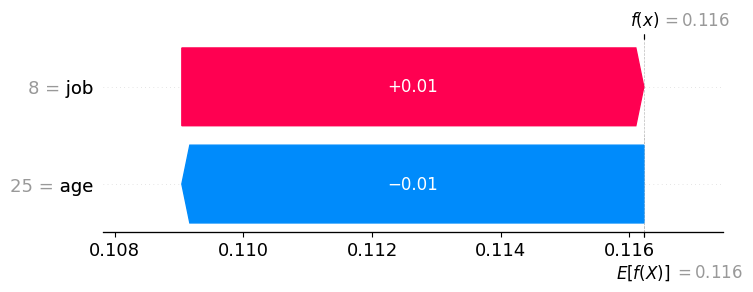

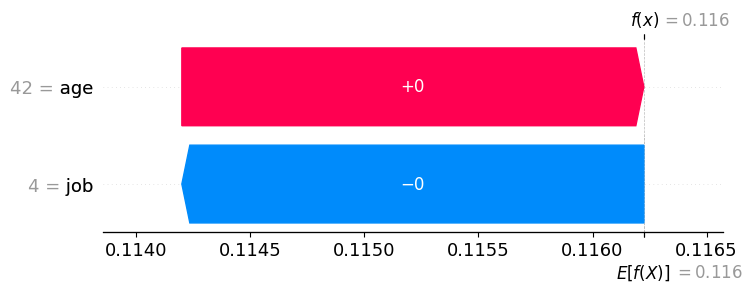

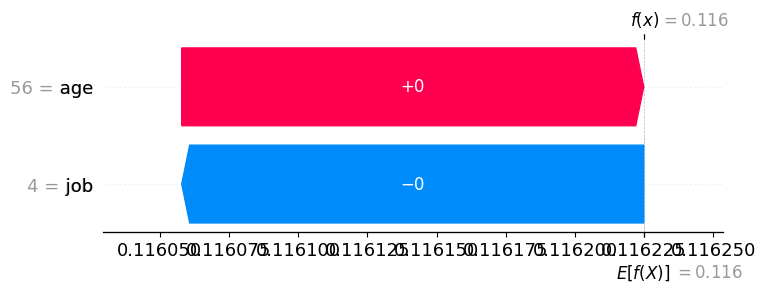

In [23]:
for i in range(5):
    explanation_object = shap.Explanation(
        values=shap_values[1][i],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[i],
        feature_names=X_test.columns
    )

    shap.plots.waterfall(explanation_object)

# **CONCLUSION**

1. The dataset was imbalanced, with most customers not subscribing, which made prediction harder.
2. Different models were tested, and Random Forest performed better than Logistic Regression in predicting results.
3. Random Forest handled complex patterns and imbalance more effectively, giving a higher F1-score.
4. Using SHAP analysis, we understood which features had the most impact on predictions.
5. Combining a strong model with explainability techniques helped in making more accurate and understandable predictions.